# Projeto: Análise de Abandono e Sucesso Académico

https://www.kaggle.com/code/jeevabharathis/student-dropout-analysis-for-school-education

A ideia principal é analisar o dataset de estudantes, perceber a distribuição das variáveis e construir uma primeira base de modelação para prever abandono escolar. Os nomes das colunas são mantidos em inglês, exatamente como vêm no dataset, para evitar confusão com documentação externa e com a fonte original.

## Célula 1 - Configuração inicial

Nesta célula são importadas as bibliotecas usadas ao longo do notebook. Também é definido um estado aleatório fixo para tornar os resultados reprodutíveis e são ajustadas algumas opções de visualização das tabelas e gráficos.

In [2]:
# Celula 1 - Configuracao inicial do ambiente
from pathlib import Path
import warnings

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.compose import ColumnTransformer, make_column_selector
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

# Evita avisos repetidos que podem dificultar a leitura
warnings.filterwarnings('ignore')

# Valor fixo para garantir que a divisao treino/teste e os modelos sao reproduziveis.
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

# Mostra mais colunas quando fazemos display de tabelas no notebook.
pd.set_option('display.max_columns', 80)
sns.set_theme(style='whitegrid')

print('Configuração concluida.')

Configuração concluida.


## Célula 2 - Carregamento do dataset

Nesta célula o notebook procura automaticamente um ficheiro `.csv` dentro da pasta `data/` e carrega-o para um `DataFrame`. O código também funciona se o notebook for aberto a partir da pasta do projeto principal ou diretamente dentro da pasta `iaa-project-1`.

Importante: aqui não são traduzidas colunas nem valores. O dataset fica com a estrutura original.

In [3]:
# Celula 2 - Localizacao e carregamento dos dados
PROJECT_ROOT = Path.cwd()
DATA_DIR = PROJECT_ROOT / 'data'

# Permite executar o notebook tanto na pasta iaa-project-1 como na pasta acima.
if not DATA_DIR.exists() and (PROJECT_ROOT / 'iaa-project-1' / 'data').exists():
    PROJECT_ROOT = PROJECT_ROOT / 'iaa-project-1'
    DATA_DIR = PROJECT_ROOT / 'data'

def find_first_csv(data_dir: Path):
    if not data_dir.exists():
        return None
    csv_files = sorted(data_dir.glob('*.csv'))
    return csv_files[0] if csv_files else None

DATA_PATH = find_first_csv(DATA_DIR)

if DATA_PATH is None:
    print("Não foi encontrado nenhum ficheiro CSV em 'data/'.")
    print('Coloca o dataset na pasta data/ ou define DATA_PATH manualmente.')
else:
    print(f'Dataset encontrado: {DATA_PATH}')

df = pd.read_csv(DATA_PATH, encoding='utf-8-sig') if DATA_PATH is not None else pd.DataFrame()

print('Dimensão do dataset:', df.shape)

Dataset encontrado: /home/mega/Desktop/code/iaa-project-1/data/dataset.csv
Dimensão do dataset: (4424, 35)


## Célula 3 - Primeira inspeção dos dados

Esta célula serve para confirmar se o dataset foi carregado corretamente. São mostradas as primeiras linhas, os tipos de dados, o número de valores em falta e o número de linhas duplicadas. Esta etapa é importante antes de qualquer modelo, porque erros de carregamento ou problemas de qualidade podem afetar toda a análise.

In [6]:
# Celula 3 - Inspecao inicial do dataset
if df.empty:
    print('DataFrame vazío. Carrega primeiro o dataset.')
else:
    display(df.head())

    print()
    print('Tipos de dados:')
    display(df.dtypes.value_counts())

    missing_values = df.isna().sum()
    duplicate_count = df.duplicated().sum()

    if missing_values.any() or duplicate_count != 0:
        print('Erro: existem valores em falta e/ou linhas duplicadas.')
        display(missing_values[missing_values > 0].sort_values(ascending=False).head(10))
        print('Número de linhas duplicadas:', duplicate_count)
    else:
        print('Validação passou: Sem valores em falta e sem linhas duplicadas.')

,Marital status,Application mode,Application order,Course,Daytime/evening attendance,Previous qualification,Nacionality,Mother's qualification,Father's qualification,Mother's occupation,Father's occupation,Displaced,Educational special needs,Debtor,Tuition fees up to date,Gender,Scholarship holder,Age at enrollment,International,Curricular units 1st sem (credited),Curricular units 1st sem (enrolled),Curricular units 1st sem (evaluations),Curricular units 1st sem (approved),Curricular units 1st sem (grade),Curricular units 1st sem (without evaluations),Curricular units 2nd sem (credited),Curricular units 2nd sem (enrolled),Curricular units 2nd sem (evaluations),Curricular units 2nd sem (approved),Curricular units 2nd sem (grade),Curricular units 2nd sem (without evaluations),Unemployment rate,Inflation rate,GDP,Target
0,1,8,5,2,1,1,1,13,10,6,10,1,0,0,1,1,0,20,0,0,0,0,0,0.000000,0,0,0,0,0,0.000000,0,10.8,1.4,1.74,Dropout
1,1,6,1,11,1,1,1,1,3,4,4,1,0,0,0,1,0,19,0,0,6,6,6,14.000000,0,0,6,6,6,13.666667,0,13.9,-0.3,0.79,Graduate
2,1,1,5,5,1,1,1,22,27,10,10,1,0,0,0,1,0,19,0,0,6,0,0,0.000000,0,0,6,0,0,0.000000,0,10.8,1.4,1.74,Dropout
3,1,8,2,15,1,1,1,23,27,6,4,1,0,0,1,0,0,20,0,0,6,8,6,13.428571,0,0,6,10,5,12.400000,0,9.4,-0.8,-3.12,Graduate
4,2,12,1,3,0,1,1,22,28,10,10,0,0,0,1,0,0,45,0,0,6,9,5,12.333333,0,0,6,6,6,13.000000,0,13.9,-0.3,0.79,Graduate



Tipos de dados:


int64      29
float64     5
object      1
Name: count, dtype: int64

Validação passou: Sem valores em falta e sem linhas duplicadas.


## Célula 4 - Estatísticas descritivas

Nesta célula são calculadas estatísticas simples das variáveis numéricas, como média, desvio padrão, mínimo e máximo. Isto ajuda a perceber a escala das variáveis e a detetar valores estranhos ou muito diferentes do esperado.

In [7]:
# Celula 4 - Estatisticas descritivas das variaveis numericas
if df.empty:
    print('DataFrame vazio.')
else:
    display(df.describe().T)

,count,mean,std,min,25%,50%,75%,max
Marital status,4424.0,1.178571,0.605747,1.00,1.00,1.000000,1.000000,6.000000
Application mode,4424.0,6.886980,5.298964,1.00,1.00,8.000000,12.000000,18.000000
Application order,4424.0,1.727848,1.313793,0.00,1.00,1.000000,2.000000,9.000000
Course,4424.0,9.899186,4.331792,1.00,6.00,10.000000,13.000000,17.000000
Daytime/evening attendance,4424.0,0.890823,0.311897,0.00,1.00,1.000000,1.000000,1.000000
Previous qualification,4424.0,2.531420,3.963707,1.00,1.00,1.000000,1.000000,17.000000
Nacionality,4424.0,1.254521,1.748447,1.00,1.00,1.000000,1.000000,21.000000
Mother's qualification,4424.0,12.322107,9.026251,1.00,2.00,13.000000,22.000000,29.000000
Father's qualification,4424.0,16.455244,11.044800,1.00,3.00,14.000000,27.000000,34.000000
Mother's occupation,4424.0,7.317812,3.997828,1.00,5.00,6.000000,10.000000,32.000000


## Célula 5 - Distribuição da variável alvo

A coluna `Target` representa o resultado académico do estudante: `Dropout`, `Enrolled` ou `Graduate`. Aqui é analisada a distribuição dessas classes. Esta informação é essencial porque, se as classes estiverem desequilibradas, a avaliação do modelo não deve depender apenas da accuracy.

,contagem,percentagem
Target,,
Graduate,2209,49.93
Dropout,1421,32.12
Enrolled,794,17.95


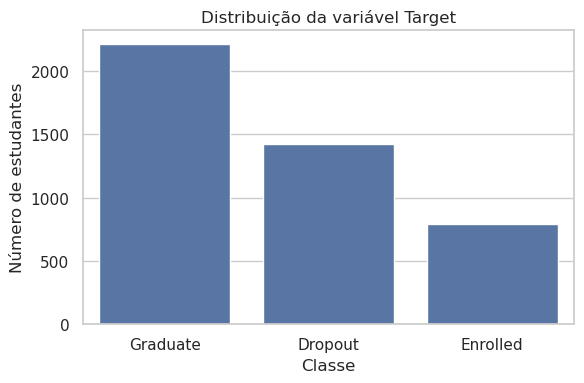

In [8]:
# Celula 5 - Analise da distribuicão da variável alvo
TARGET_COL = 'Target'

if df.empty:
    print('DataFrame vazio.')
elif TARGET_COL not in df.columns:
    print(f"Coluna '{TARGET_COL}' não encontrada.")
    print('Colunas disponíveis:')
    display(df.columns.to_series())
else:
    target_counts = df[TARGET_COL].value_counts(dropna=False)
    target_percentages = df[TARGET_COL].value_counts(normalize=True, dropna=False).mul(100).round(2)

    target_summary = pd.DataFrame({
        'contagem': target_counts,
        'percentagem': target_percentages
    })
    display(target_summary)

    plt.figure(figsize=(6, 4))
    sns.countplot(data=df, x=TARGET_COL, order=target_counts.index)
    plt.title('Distribuição da variável Target')
    plt.xlabel('Classe')
    plt.ylabel('Número de estudantes')
    plt.tight_layout()
    plt.show()

## Célula 6 - Relações entre variáveis académicas e Target

Nesta célula são escolhidas algumas variáveis académicas importantes, especialmente relacionadas com unidades curriculares aprovadas e notas. O objetivo é observar visualmente se existem diferenças entre estudantes que abandonam, continuam inscritos ou se graduam.

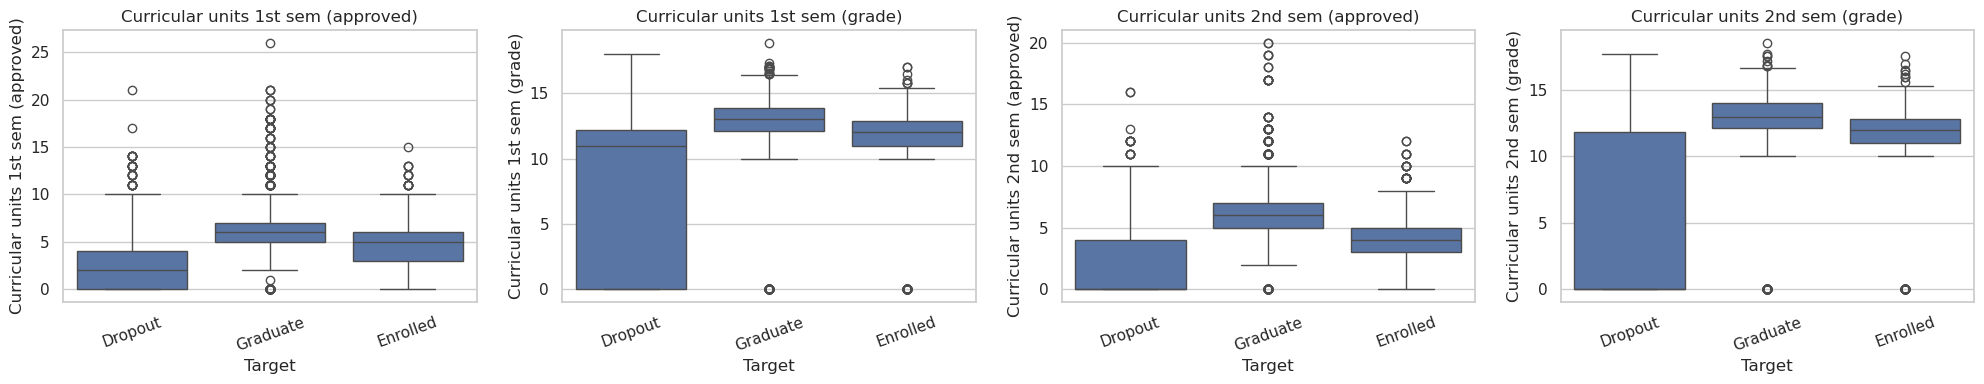

In [9]:
# Celula 6 - Exploracao visual de variaveis academicas relevantes
academic_features = [
    'Curricular units 1st sem (approved)',
    'Curricular units 1st sem (grade)',
    'Curricular units 2nd sem (approved)',
    'Curricular units 2nd sem (grade)'
]

if df.empty or TARGET_COL not in df.columns:
    print('Dados insuficientes para gerar graficos.')
else:
    available_features = [col for col in academic_features if col in df.columns]

    if not available_features:
        print('Nenhuma das variaveis academicas esperadas foi encontrada.')
    else:
        fig, axes = plt.subplots(1, len(available_features), figsize=(5 * len(available_features), 4))
        if len(available_features) == 1:
            axes = [axes]

        for ax, feature in zip(axes, available_features):
            sns.boxplot(data=df, x=TARGET_COL, y=feature, ax=ax)
            ax.set_title(feature)
            ax.set_xlabel('Target')
            ax.tick_params(axis='x', rotation=20)

        plt.tight_layout()
        plt.show()

## Célula 7 - Matriz de correlação

Esta célula mostra uma matriz de correlação para variáveis numéricas selecionadas. A correlação ajuda a perceber que variáveis tendem a variar em conjunto. Nesta fase serve sobretudo como apoio exploratório, não como prova de causalidade.

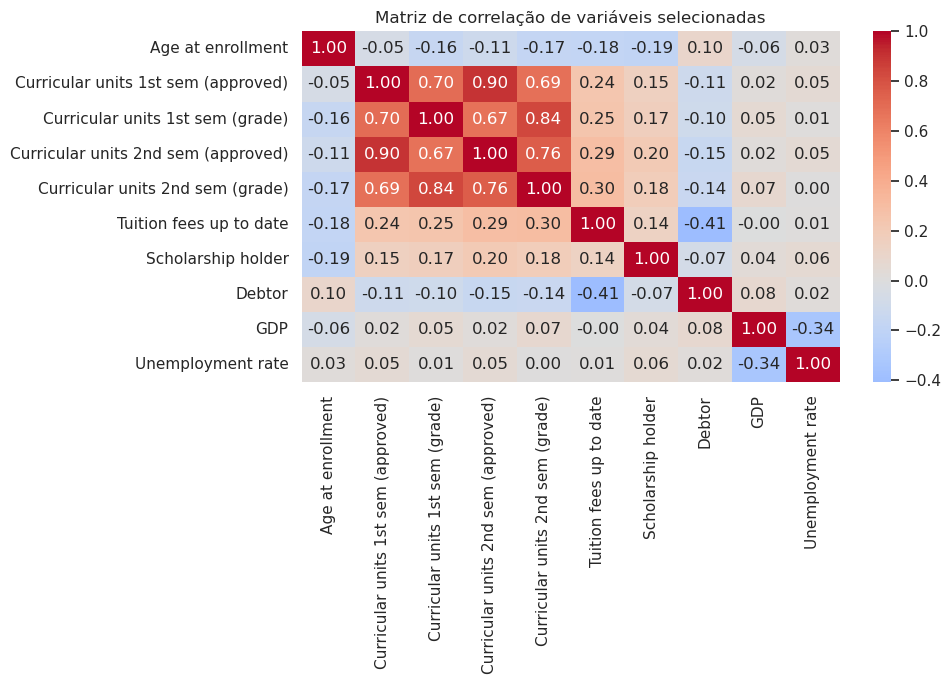

In [11]:
# Celula 7 - Correlação entre variaveis numericas selecionadas
if df.empty:
    print('DataFrame vazio.')
else:
    numeric_df = df.select_dtypes(include=np.number)
    selected_numeric_cols = [
        'Age at enrollment',
        'Curricular units 1st sem (approved)',
        'Curricular units 1st sem (grade)',
        'Curricular units 2nd sem (approved)',
        'Curricular units 2nd sem (grade)',
        'Tuition fees up to date',
        'Scholarship holder',
        'Debtor',
        'GDP',
        'Unemployment rate'
    ]
    selected_numeric_cols = [col for col in selected_numeric_cols if col in numeric_df.columns]

    if len(selected_numeric_cols) < 2:
        print('Variáveis numericas insuficientes para calcular correlação.')
    else:
        corr = numeric_df[selected_numeric_cols].corr()
        plt.figure(figsize=(10, 7))
        sns.heatmap(corr, cmap='coolwarm', center=0, annot=True, fmt='.2f')
        plt.title('Matriz de correlação de variáveis selecionadas')
        plt.tight_layout()
        plt.show()

## Célula 8 - Preparação do problema binário

Embora o dataset tenha três classes, para uma primeira etapa faz sentido focar o problema mais direto: distinguir estudantes em `Dropout` dos restantes. Assim, é criada uma nova variável `target_binary`, em que `1` representa abandono e `0` representa não abandono.

Depois os dados são divididos em treino e teste, mantendo a proporção das classes através de `stratify`.

In [14]:
# Celula 8 - Criacao do alvo binario e divisao treino/teste
if df.empty or TARGET_COL not in df.columns:
    print('Nao e possivel preparar dados sem dataset ou coluna Target.')
else:
    work_df = df.copy()

    # 1 significa estudante em abandono; 0 significa estudante inscrito ou graduado.
    work_df['target_binary'] = np.where(work_df[TARGET_COL].astype(str).str.lower() == 'dropout', 1, 0)

    X = work_df.drop(columns=[TARGET_COL, 'target_binary'])
    y_binary = work_df['target_binary']

    X_train, X_test, y_train, y_test = train_test_split(
        X,
        y_binary,
        test_size=0.2,
        random_state=RANDOM_STATE,
        stratify=y_binary
    )

    print('Tamanho do treino:', X_train.shape)
    print('Tamanho do teste:', X_test.shape)
    print()
    print('Distribuicao do alvo binario no treino:')
    display(y_train.value_counts(normalize=True).rename('proporcao'))

Tamanho do treino: (3539, 34)
Tamanho do teste: (885, 34)

Distribuicao do alvo binario no treino:


target_binary
0    0.678723
1    0.321277
Name: proporcao, dtype: float64

## Célula 9 - Pipeline de pré-processamento

Nesta célula é definido o pré-processamento usado antes dos modelos. Variáveis numéricas recebem imputação pela mediana e normalização; variáveis categóricas recebem imputação pelo valor mais frequente e codificação one-hot. Mesmo que quase todas as variáveis sejam numéricas neste dataset, usar uma pipeline torna o processo mais robusto e organizado.

In [15]:
# Celula 9 - Definição do pré-processamento
if df.empty or TARGET_COL not in df.columns:
    print('Dados insuficientes para criar o pré-processamento.')
else:
    numeric_selector = make_column_selector(dtype_include=np.number)
    categorical_selector = make_column_selector(dtype_exclude=np.number)

    numeric_pipeline = Pipeline([
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler', StandardScaler())
    ])

    categorical_pipeline = Pipeline([
        ('imputer', SimpleImputer(strategy='most_frequent')),
        ('onehot', OneHotEncoder(handle_unknown='ignore'))
    ])

    preprocessor = ColumnTransformer([
        ('numeric', numeric_pipeline, numeric_selector),
        ('categorical', categorical_pipeline, categorical_selector)
    ])

    print('Pré-processamento definido.')

Pre-processamento definido.


## Célula 10 - Modelos de referência

Nesta célula são treinados e comparados dois modelos iniciais: Regressão Logística e Random Forest. A Regressão Logística funciona como modelo mais simples e interpretável; a Random Forest permite capturar relações não lineares.

A comparação é feita com validação cruzada estratificada e várias métricas, para dar uma visão mais completa do desempenho.

In [16]:
# Celula 10 - Comparacao inicial de modelos com validacao cruzada
if df.empty or TARGET_COL not in df.columns:
    print('Dados insuficientes para treinar modelos.')
else:
    models = {
        'Logistic Regression': LogisticRegression(max_iter=2000, class_weight='balanced', random_state=RANDOM_STATE),
        'Random Forest': RandomForestClassifier(n_estimators=400, class_weight='balanced', random_state=RANDOM_STATE)
    }

    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
    scoring = ['accuracy', 'f1', 'precision', 'recall', 'roc_auc']

    cv_results = []

    for model_name, model in models.items():
        pipeline = Pipeline([
            ('preprocessor', preprocessor),
            ('model', model)
        ])

        scores = cross_validate(
            pipeline,
            X_train,
            y_train,
            cv=cv,
            scoring=scoring,
            n_jobs=1
        )

        summary = {metric: float(np.mean(scores[f'test_{metric}'])) for metric in scoring}
        summary['model'] = model_name # pyright: ignore[reportArgumentType]
        cv_results.append(summary)

    cv_results_df = pd.DataFrame(cv_results).set_index('model').sort_values('f1', ascending=False)
    display(cv_results_df)

,accuracy,f1,precision,recall,roc_auc
model,,,,,
Logistic Regression,0.861262,0.790835,0.769845,0.814433,0.918718
Random Forest,0.870306,0.775466,0.873642,0.697426,0.916116


## Célula 11 - Avaliação no conjunto de teste

Depois da validação cruzada, o melhor modelo é treinado no conjunto de treino completo e avaliado no conjunto de teste. O relatório mostra precision, recall e F1 para cada classe. A matriz de confusão permite ver quantos casos foram classificados corretamente e onde aconteceram os principais erros.

Melhor modelo: Logistic Regression

Relatório de classificação:
              precision    recall  f1-score   support

 Non-Dropout     0.9167    0.8968    0.9066       601
     Dropout     0.7912    0.8275    0.8090       284

    accuracy                         0.8746       885
   macro avg     0.8540    0.8622    0.8578       885
weighted avg     0.8764    0.8746    0.8753       885



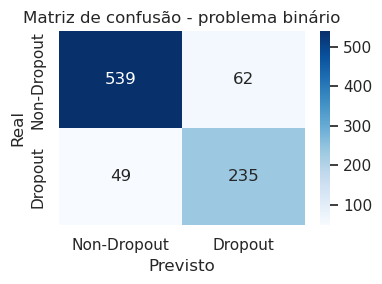

In [19]:
# Celula 11 - Avaliacao final do melhor modelo no conjunto de teste
if df.empty or TARGET_COL not in df.columns:
    print('Dados insuficientes para a avaliação final.')
else:
    best_model_name = cv_results_df.index[0]
    best_model = models[best_model_name]

    best_pipeline = Pipeline([
        ('preprocessor', preprocessor),
        ('model', best_model)
    ])

    best_pipeline.fit(X_train, y_train)
    y_pred = best_pipeline.predict(X_test)

    print('Melhor modelo:', best_model_name)
    print()
    print('Relatório de classificação:')
    print(classification_report(y_test, y_pred, target_names=['Non-Dropout', 'Dropout'], digits=4))

    cm = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(4, 3))
    sns.heatmap(
        cm,
        annot=True,
        fmt='d',
        cmap='Blues',
        xticklabels=['Non-Dropout', 'Dropout'],
        yticklabels=['Non-Dropout', 'Dropout']
    )
    plt.title('Matriz de confusão - problema binário')
    plt.xlabel('Previsto')
    plt.ylabel('Real')
    plt.tight_layout()
    plt.show()

## Célula 12 - Importância das variáveis

Esta célula mostra as variáveis com maior importância segundo o modelo Random Forest. Isto ajuda a explicar que fatores estão a influenciar mais a previsão. Se o melhor modelo for outro, a célula informa que esta visualização ainda não se aplica diretamente.

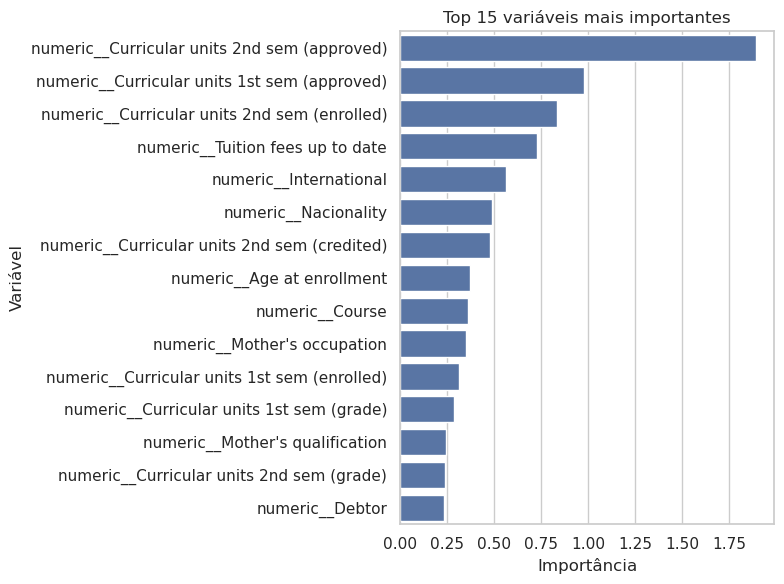

In [21]:
# Celula 12 - Importância das variáveis para Random Forest
if df.empty or TARGET_COL not in df.columns:
    print('Dados insuficientes para calcular importância de variáveis.')
#elif best_model_name != 'Random Forest':
#    print('O melhor modelo atual não é Random Forest; por isso esta visualização fica como próximo passo.')
else:
    fitted_preprocessor = best_pipeline.named_steps['preprocessor']
    fitted_model = best_pipeline.named_steps['model']

    feature_names = fitted_preprocessor.get_feature_names_out()
    if hasattr(fitted_model, 'feature_importances_'):
        importances = pd.Series(fitted_model.feature_importances_, index=feature_names)
    elif hasattr(fitted_model, 'coef_'):
        coefs = fitted_model.coef_
        if coefs.ndim == 1 or coefs.shape[0] == 1:
            coef_vals = np.abs(coefs.ravel())
        else:
            coef_vals = np.abs(coefs).sum(axis=0)
        importances = pd.Series(coef_vals, index=feature_names)
    else:
        print('O modelo não fornece feature_importances_ nem coef_. Usando zeros como fallback.')
        importances = pd.Series(0.0, index=feature_names)
    top_importances = importances.sort_values(ascending=False).head(15)

    plt.figure(figsize=(8, 6))
    sns.barplot(x=top_importances.values, y=top_importances.index)
    plt.title('Top 15 variáveis mais importantes')
    plt.xlabel('Importância')
    plt.ylabel('Variável')
    plt.tight_layout()
    plt.show()

## Estado atual e próximos passos

O notebook já tem uma base apresentável para mostrar progresso: carregamento dos dados, exploração inicial, análise da variável alvo, observação de variáveis académicas, preparação do alvo binário, pipeline de pré-processamento, comparação entre modelos e avaliação no teste.

Próximos passos naturais:

- Confirmar a interpretação das variáveis codificadas numericamente;
- Testar mais modelos e afinar hiperparâmetros;
- Avaliar também o problema multiclasse original (`Dropout`, `Enrolled`, `Graduate`);
- Medir desempenho por subgrupos como `Gender`, `Scholarship holder` ou `Debtor`;
- Preparar uma conclusão curta com os principais resultados obtidos.